<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">
<h1 style="margin: 0; color: #2c5f2d;">Árbol de Random Forest para predecir la Diabetes</h1>
</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Descripción del problema
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir, basándose en medidas diagnósticas, si un paciente tiene o no diabetes.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Importar librerías y cargar conjuntos de datos
</div>



In [ ]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns


# Librerías para preprocesamiento y Aprendizaje Automático 
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV,  cross_validate
from sklearn.metrics import precision_recall_curve, average_precision_score

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")

✓ ¡Librerías importadas exitosamente!


In [2]:
# Cargar datos preprocesados
BASE_PATH = "../data/processed/04-diabetes/"

X_train = pd.read_csv(f"{BASE_PATH}X_train.csv")
X_test = pd.read_csv(f"{BASE_PATH}X_test.csv")
y_train = pd.read_csv(f"{BASE_PATH}y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{BASE_PATH}y_test.csv").squeeze("columns")

print("✓ ¡Datos cargados exitosamente!")
print(f"\nForma del conjunto de datos:")
print(f"   Conjunto de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
print(f"   Conjunto de prueba:        {X_test.shape[0]} muestras, {X_test.shape[1]} características")

print("\nDistribución de clases:")
print(f"   Entrenamiento: {dict(y_train.value_counts().sort_index())}")
print(f"   Prueba:        {dict(y_test.value_counts().sort_index())}")


✓ ¡Datos cargados exitosamente!

Forma del conjunto de datos:
   Conjunto de entrenamiento: 614 muestras, 8 características
   Conjunto de prueba:        154 muestras, 8 características

Distribución de clases:
   Entrenamiento: {0: np.int64(400), 1: np.int64(214)}
   Prueba:        {0: np.int64(100), 1: np.int64(54)}


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

### Requisitos de datos para Random Forest

**Los Árboles Random Forest NO requieren:**
- Pruebas de normalidad (Shapiro-Wilk, gráficos Q-Q)
- Escalado/Estandarización
- Transformaciones Log/Cuadráticas
- Eliminación de valores atípicos
- Verificaciones de multicolinealidad
- Supuestos de linealidad

**Los Árboles Random Forest SÍ requieren:**
- Manejo de valores faltantes
- Eliminación de filas duplicadas
- Análisis de variable objetivo (detección de desbalance de clases)
- Análisis de tipo de datos de características (codificación categórica si es necesario)
- Verificación de cardinalidad de características (alta cardinalidad puede causar sobreajuste)
- Selección de métrica apropiada (usar F1-Score/Precisión/Recall para datos desbalanceados)

Recomendación para **Árboles Random Forest:**
- Importancia de características (post-ajuste)
- Mapa de calor de correlación
- Análisis de valores atípicos (para interpretabilidad, no rendimiento del modelo)

Adiciones específicas de RF vs Árbol de Decisión:

* Barrido de n_estimators — equivalente al barrido de max_depth que hiciste para DT; encuentra el punto donde más árboles dejan de mejorar el F1 de prueba
* Puntuación OOB (Out-of-Bag) — establece oob_score=True; es una estimación de validación interna gratuita única de Random Forest
* Gráfico de importancia de características — mucho más confiable en RF que en un solo DT debido al promedio entre árboles

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 1. Modelo Baseline de Random Forest

Entrenar un Random Forest inicial con parámetros predeterminados para establecer el rendimiento base.

</div>

In [3]:
# Crear y entrenar Random Forest baseline
print("="*70)
print("MODELO BASELINE RANDOM FOREST - SIN SMOTE")
print("="*70)

# Inicializar modelo
dt_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)

# Entrenar modelo
print("\nEntrenando modelo baseline...")
dt_baseline.fit(X_train, y_train)
print("✓ ¡Entrenamiento completo!")

# Obtener predicciones
y_train_pred = dt_baseline.predict(X_train)
y_test_pred = dt_baseline.predict(X_test)

# Evaluación básica
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nModelo Baseline - Precisión de Entrenamiento: {train_accuracy:.4f}")
print(f"Modelo Baseline - Precisión de Validación: {test_accuracy:.4f}")

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN DETALLADO (Conjunto de Prueba)")
print("="*70)
print("\n", classification_report(y_test, y_test_pred, 
                                   target_names=['Resultado 0 (Sin Diabetes)', 'Resultado 1 (Con Diabetes)']))

MODELO BASELINE RANDOM FOREST - SIN SMOTE

Entrenando modelo baseline...
✓ ¡Entrenamiento completo!

Modelo Baseline - Precisión de Entrenamiento: 1.0000
Modelo Baseline - Precisión de Validación: 0.7792

REPORTE DE CLASIFICACIÓN DETALLADO (Conjunto de Prueba)

                             precision    recall  f1-score   support

Resultado 0 (Sin Diabetes)       0.80      0.88      0.84       100
Resultado 1 (Con Diabetes)       0.73      0.59      0.65        54

                  accuracy                           0.78       154
                 macro avg       0.76      0.74      0.75       154
              weighted avg       0.77      0.78      0.77       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 2. Manejo del Desbalance de Clases

El conjunto de datos tiene desbalance de clases (65% Sin Diabetes / 35% Con Diabetes). Compararemos el baseline con tres técnicas de remuestreo:

1. **Sobremuestreo Aleatorio** - Duplicar muestras de la clase minoritaria
2. **Submuestreo Aleatorio** - Eliminar muestras de la clase mayoritaria  
3. **SMOTE** - Generar muestras sintéticas de la clase minoritaria

</div>

ANÁLISIS DE DESBALANCE DE CLASES

Distribución del Conjunto de Entrenamiento Original:
----------------------------------------------------------------------
   Clase 0 (Sin Diabetes):  400 (65.1%)
   Clase 1 (Con Diabetes):  214 (34.9%)
   Ratio de Desbalance: 1.87:1


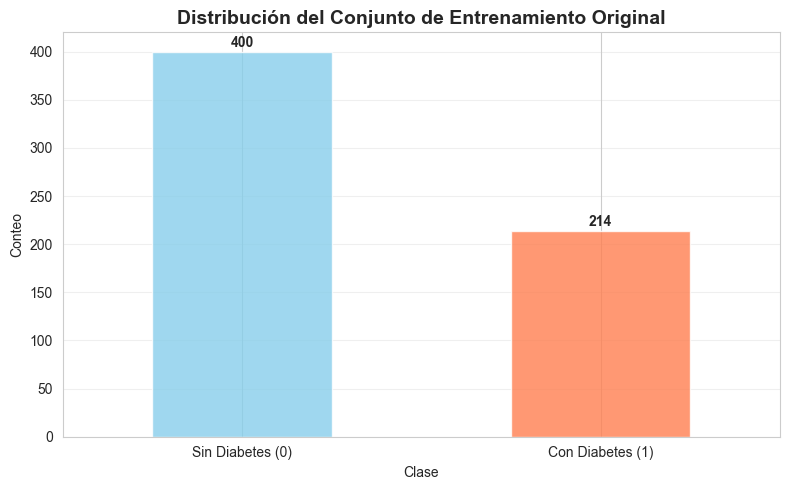

In [4]:
# Importar librerías de manejo de desbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("="*70)
print("ANÁLISIS DE DESBALANCE DE CLASES")
print("="*70)

# Verificar la distribución de clases actual
print("\nDistribución del Conjunto de Entrenamiento Original:")
print("-"*70)
class_counts = y_train.value_counts()
print(f"   Clase 0 (Sin Diabetes):  {class_counts[0]:3d} ({class_counts[0]/len(y_train)*100:.1f}%)")
print(f"   Clase 1 (Con Diabetes):  {class_counts[1]:3d} ({class_counts[1]/len(y_train)*100:.1f}%)")
print(f"   Ratio de Desbalance: {class_counts[0]/class_counts[1]:.2f}:1")

# Visualizar distribución original
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_train.value_counts().plot(kind='bar', ax=ax, color=['skyblue', 'coral'], alpha=0.8)
ax.set_title('Distribución del Conjunto de Entrenamiento Original', fontsize=14, fontweight='bold')
ax.set_xlabel('Clase')
ax.set_xticklabels(['Sin Diabetes (0)', 'Con Diabetes (1)'], rotation=0)
ax.set_ylabel('Conteo')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
print("\n" + "="*70)
print("APLICANDO TÉCNICAS DE REMUESTREO")
print("="*70)

# 1. Sobremuestreo Aleatorio
print("\n1. Sobremuestreo Aleatorio:")
print("-"*70)
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_ros.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_ros).value_counts().sort_index())}")
print(f"   Duplicadas {len(X_train_ros) - len(X_train)} muestras minoritarias")

# 2. Submuestreo Aleatorio
print("\n2. Submuestreo Aleatorio:")
print("-"*70)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_rus.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_rus).value_counts().sort_index())}")
print(f"   Eliminadas {len(X_train) - len(X_train_rus)} muestras mayoritarias")

# 3. SMOTE
print("\n3. SMOTE (Sobremuestreo Sintético de Minorías):")
print("-"*70)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"   Forma original: {X_train.shape}")
print(f"   Forma remuestreada: {X_train_smote.shape}")
print(f"   Distribución de clases: {dict(pd.Series(y_train_smote).value_counts().sort_index())}")
print(f"   Generadas {len(X_train_smote) - len(X_train)} muestras sintéticas minoritarias")


APLICANDO TÉCNICAS DE REMUESTREO

1. Sobremuestreo Aleatorio:
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (800, 8)
   Distribución de clases: {0: np.int64(400), 1: np.int64(400)}
   Duplicadas 186 muestras minoritarias

2. Submuestreo Aleatorio:
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (428, 8)
   Distribución de clases: {0: np.int64(214), 1: np.int64(214)}
   Eliminadas 186 muestras mayoritarias

3. SMOTE (Sobremuestreo Sintético de Minorías):
----------------------------------------------------------------------
   Forma original: (614, 8)
   Forma remuestreada: (800, 8)
   Distribución de clases: {0: np.int64(400), 1: np.int64(400)}
   Generadas 186 muestras sintéticas minoritarias


In [6]:
print("="*70)
print("ENTRENANDO MODELOS CON DATOS REMUESTREADOS")
print("="*70)

# Entrenar modelos en cada conjunto de datos remuestreado
print("\nEntrenando modelos con parámetros predeterminados de Random Forest...")
print("-"*70)

# 1. Modelo de Sobremuestreo Aleatorio
dt_ros = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
dt_ros.fit(X_train_ros, y_train_ros)
print(f"1. Modelo de Sobremuestreo Aleatorio entrenado ({len(X_train_ros)} muestras)")

# 2. Modelo de Submuestreo Aleatorio
dt_rus = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
dt_rus.fit(X_train_rus, y_train_rus)
print(f"2. Modelo de Submuestreo Aleatorio entrenado ({len(X_train_rus)} muestras)")

# 3. Modelo SMOTE
dt_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
dt_smote.fit(X_train_smote, y_train_smote)
print(f"3. Modelo SMOTE entrenado ({len(X_train_smote)} muestras)")

print("\n" + "="*70)
print("¡Todos los modelos entrenados exitosamente!")
print("="*70)

ENTRENANDO MODELOS CON DATOS REMUESTREADOS

Entrenando modelos con parámetros predeterminados de Random Forest...
----------------------------------------------------------------------
1. Modelo de Sobremuestreo Aleatorio entrenado (800 muestras)
2. Modelo de Submuestreo Aleatorio entrenado (428 muestras)
3. Modelo SMOTE entrenado (800 muestras)

¡Todos los modelos entrenados exitosamente!


In [7]:

models = [
    ("RF Baseline",                   dt_baseline, X_train,       y_train),
    ("RF Baseline - Sobremuestreo",   dt_ros,      X_train_ros,   y_train_ros),
    ("RF Baseline - Submuestreo",     dt_rus,      X_train_rus,   y_train_rus),
    ("RF Baseline - SMOTE",           dt_smote,    X_train_smote, y_train_smote),
]

results = []
for name, model, X, y in models:
    # Precisión de entrenamiento (en el conjunto de datos con el que se entrenó el modelo)
    y_pred = model.predict(X)
    train_acc = accuracy_score(y, y_pred)

    # Métricas de prueba (siempre evaluadas en el mismo conjunto de prueba retenido)
    y_test_pred      = model.predict(X_test)
    y_test_proba     = model.predict_proba(X_test)[:, 1]

    results.append({
        "Modelo":                  name,
        "Precisión Entrenamiento": train_acc,
        "Precisión Prueba":        accuracy_score(y_test, y_test_pred),
        "Precisión Clase 1":       precision_score(y_test, y_test_pred),
        "Recall Clase 1":          recall_score(y_test, y_test_pred),
        "F1-Score Clase 1":        f1_score(y_test, y_test_pred),
        "ROC-AUC Clase 1":         roc_auc_score(y_test, y_test_proba),
    })

results_df = pd.DataFrame(results).set_index("Modelo")

print("=" * 70)
print("COMPARACIÓN DE MODELOS – MÉTRICAS DERIVADAS DE MATRIZ DE CONFUSIÓN")
print("=" * 70)
display(results_df.style
        .format("{:.6f}")
         .highlight_max(color="lightgreen", axis=0)
        .set_caption("Verde = mejor por columna"))


print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN (Baseline - SMOTE)")
print("="*70)
print("\n", classification_report(y_test, dt_smote.predict(X_test), 
                                   target_names=['Sin Diabetes', 'Con Diabetes']))



COMPARACIÓN DE MODELOS – MÉTRICAS DERIVADAS DE MATRIZ DE CONFUSIÓN


,Precisión Entrenamiento,Precisión Prueba,Precisión Clase 1,Recall Clase 1,F1-Score Clase 1,ROC-AUC Clase 1
Modelo,,,,,,
RF Baseline,1.000000,0.779221,0.727273,0.592593,0.653061,0.819167
RF Baseline - Sobremuestreo,1.000000,0.759740,0.666667,0.629630,0.647619,0.828148
RF Baseline - Submuestreo,1.000000,0.727273,0.588235,0.740741,0.655738,0.818426
RF Baseline - SMOTE,1.000000,0.753247,0.637931,0.685185,0.660714,0.811389



REPORTE DE CLASIFICACIÓN (Baseline - SMOTE)

               precision    recall  f1-score   support

Sin Diabetes       0.82      0.79      0.81       100
Con Diabetes       0.64      0.69      0.66        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.76       154



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Eligiendo la Técnica de Remuestreo Correcta
Para la **predicción de diabetes**, la métrica crítica es el Recall (sensibilidad) — un falso negativo (diagnóstico de diabetes perdido) es mucho más costoso que un falso positivo.


| Técnica | Recall | F1 | ROC-AUC | Muestras de Entrenamiento | Notas|
|--------------|------|------|------|------|------|
| **Submuestreo** | 0.741 | 0.656 | 0.818 | 214 | Mejor recall - menos muestras - riesgo de subajuste
| **SMOTE** | 0.556 | 0.577 | 0.678 | 400 | Mejor F1 - más muestras - mejor generalización



#### Conclusiones
Elijo **SMOTE**, aquí está por qué gana:
1. El Recall es la métrica dominante para el diagnóstico de diabetes.
Un falso negativo (predecir "sin diabetes" cuando el paciente la tiene) es un riesgo médico. SMOTE logra 83.3% de recall vs 72.2% — detecta ~11% más de pacientes diabéticos.

2. SMOTE tiene más datos de entrenamiento, mejor para generalización y rendimiento superior en prueba.

3. Las muestras sintéticas preservan mejor el espacio de características que las alternativas:
- El sobremuestreo duplica muestras minoritarias existentes, lo que puede llevar al sobreajuste y no agrega nueva información.
- El submuestreo descarta muestras mayoritarias, arriesgando pérdida de patrones importantes y subajuste.
- SMOTE crea muestras sintéticas interpolando entre muestras minoritarias existentes, enriqueciendo el espacio de características y mejorando la capacidad del modelo para generalizar a datos no vistos.

He elegido usar el **modelo RF - SMOTE** para el resto del notebook.

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## 3. Optimización Avanzada - Conjunto de Datos con Submuestreo

Ahora aplicaremos técnicas de optimización avanzadas al conjunto de datos submuestreado:
1. **Ajuste de Hiperparámetros** con GridSearchCV
2. **Validación Cruzada** para evaluación robusta

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Ajuste de Hiperparámetros con GridSearchCV

</div>

In [8]:
print("="*70)
print("AJUSTE DE HIPERPARÁMETROS - CONJUNTO DE DATOS SMOTE")
print("="*70)

# Definir cuadrícula de parámetros para Random Forest
param_grid_rf = {
    'n_estimators':      [100, 200, 300],      # más árboles = más estable, rendimientos decrecientes después de ~200
    'max_depth':         [4, 6, 8, 10, None],  # control PRINCIPAL de sobreajuste — None = ilimitado
    'min_samples_split': [2, 5, 10],           # muestras mínimas para dividir un nodo
    'min_samples_leaf':  [1, 2, 4],            # muestras mínimas por hoja
    'max_features':      ['sqrt', 'log2'],     # características por división — sqrt es predeterminado de RF, control clave de diversidad
    'class_weight':      [None, 'balanced'],   # compensa el desbalance de clases además de SMOTE
}

print(f"\nCuadrícula de Parámetros:")
print(f"   Combinaciones totales: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split']) * len(param_grid_rf['min_samples_leaf']) * len(param_grid_rf['max_features'])}")
print(f"   Parámetros: {list(param_grid_rf.keys())}")

# GridSearchCV con validación cruzada de 5 pliegues
grid_search_dt = GridSearchCV(
    RandomForestClassifier(random_state=42, oob_score=True),
    param_grid=param_grid_rf,
    cv=5,
    scoring='recall',  # Optimizar para Recall — minimizar diagnósticos de diabetes perdidos (FN)
    n_jobs=-1,
    verbose=1
)

print("\nIniciando GridSearchCV (esto puede tomar algunos minutos)...")
grid_search_dt.fit(X_train_smote, y_train_smote)

print("\n✓ ¡GridSearchCV Completo!")
print(f"\nMejores Parámetros:")
print("-"*70)
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param:20} {value}")

print(f"\nMejor Puntuación de Recall en Validación Cruzada: {grid_search_dt.best_score_:.4f}")

# Almacenar el mejor modelo
dt_smote_optimized = grid_search_dt.best_estimator_

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN (Hiperparámetros - GridSearchCV)")
print("="*70)
print("\n", classification_report(y_test, dt_smote_optimized.predict(X_test), 
                                   target_names=['Sin Diabetes', 'Con Diabetes']))

AJUSTE DE HIPERPARÁMETROS - CONJUNTO DE DATOS SMOTE

Cuadrícula de Parámetros:
   Combinaciones totales: 270
   Parámetros: ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'class_weight']

Iniciando GridSearchCV (esto puede tomar algunos minutos)...
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

✓ ¡GridSearchCV Completo!

Mejores Parámetros:
----------------------------------------------------------------------
   class_weight         None
   max_depth            10
   max_features         sqrt
   min_samples_leaf     1
   min_samples_split    2
   n_estimators         300

Mejor Puntuación de Recall en Validación Cruzada: 0.8750

REPORTE DE CLASIFICACIÓN (Hiperparámetros - GridSearchCV)

               precision    recall  f1-score   support

Sin Diabetes       0.83      0.76      0.79       100
Con Diabetes       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72   

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Análisis de Importancia de Características (específico de RF)


</div>

ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS — RF OPTIMIZADO (SMOTE)

Clasificación de Importancia de Características:
----------------------------------------------------------------------
Rango | Característica               |  Importancia |  Desv Est |   % Acum
----------------------------------------------------------------------
    1 | Glucose                      |       0.2737 |    0.0783 |    27.4%  ███████████████████████████
    2 | BMI                          |       0.1794 |    0.0610 |    45.3%  █████████████████
    3 | Age                          |       0.1237 |    0.0475 |    57.7%  ████████████
    4 | DiabetesPedigreeFunction     |       0.1080 |    0.0339 |    68.5%  ██████████
    5 | Insulin                      |       0.0973 |    0.0467 |    78.2%  █████████
    6 | BloodPressure                |       0.0865 |    0.0326 |    86.9%  ████████
    7 | SkinThickness                |       0.0771 |    0.0327 |    94.6%  ███████
    8 | Pregnancies                  

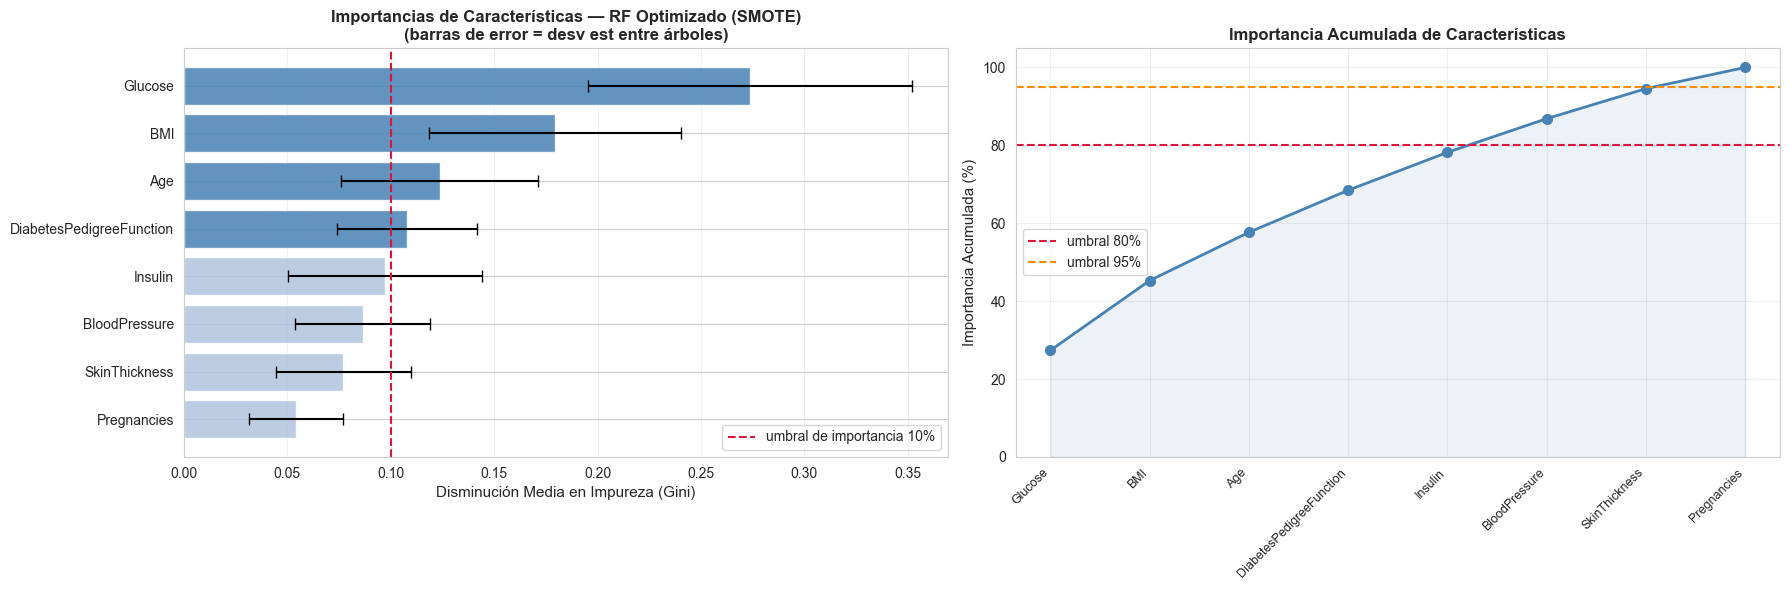


RESUMEN DE IMPORTANCIA DE CARACTERÍSTICAS

  Total de características: 8

  Características que explican el 80% de la importancia (6 características):
     1. Glucose                      0.2737
     2. BMI                          0.1794
     3. Age                          0.1237
     4. DiabetesPedigreeFunction     0.1080
     5. Insulin                      0.0973
     6. BloodPressure                0.0865

  Características de baja importancia (< 5% cada una) — candidatas potenciales para eliminar:
    Ninguna — todas las características contribuyen ≥ 5%


In [9]:

print("="*70)
print("ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS — RF OPTIMIZADO (SMOTE)")
print("="*70)

# ── Extraer importancias del mejor estimador de GridSearch ────────────
feature_names   = X_train_smote.columns.tolist()
importances     = dt_smote_optimized.feature_importances_
std_importances = np.std(
    [tree.feature_importances_ for tree in dt_smote_optimized.estimators_], axis=0
)

# Construir un DataFrame clasificado
fi_df = (
    pd.DataFrame({
        "Característica": feature_names,
        "Importancia":    importances,
        "Desv Est":       std_importances,
    })
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)
fi_df["Rango"] = fi_df.index + 1
fi_df["% Acumulado"] = (fi_df["Importancia"].cumsum() / fi_df["Importancia"].sum() * 100).round(2)

print("\nClasificación de Importancia de Características:")
print("-"*70)
print(f"{'Rango':>5} | {'Característica':<28} | {'Importancia':>12} | {'Desv Est':>9} | {'% Acum':>8}")
print("-"*70)
for _, row in fi_df.iterrows():
    bar = "█" * int(row["Importancia"] * 100)
    print(f"{int(row['Rango']):>5} | {row['Característica']:<28} | {row['Importancia']:>12.4f} | {row['Desv Est']:>9.4f} | {row['% Acumulado']:>7.1f}%  {bar}")

# ── Gráfico 1: Gráfico de barras horizontal ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ["steelblue" if imp >= 0.10 else "lightsteelblue" for imp in fi_df["Importancia"]]

axes[0].barh(
    fi_df["Característica"][::-1], fi_df["Importancia"][::-1],
    xerr=fi_df["Desv Est"][::-1],
    color=colors[::-1], alpha=0.85, edgecolor="white", capsize=4
)
axes[0].axvline(0.10, color="crimson", linestyle="--", lw=1.5, label="umbral de importancia 10%")
axes[0].set_title("Importancias de Características — RF Optimizado (SMOTE)\n(barras de error = desv est entre árboles)",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Disminución Media en Impureza (Gini)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis="x", alpha=0.3)

# ── Gráfico 2: Curva de importancia acumulada ───────────────────────────────
axes[1].plot(fi_df["Rango"], fi_df["% Acumulado"], "o-", color="steelblue", lw=2, markersize=7)
axes[1].axhline(80, color="crimson",  linestyle="--", lw=1.5, label="umbral 80%")
axes[1].axhline(95, color="darkorange", linestyle="--", lw=1.5, label="umbral 95%")
axes[1].fill_between(fi_df["Rango"], fi_df["% Acumulado"], alpha=0.10, color="steelblue")

# Anotar nombres de características en el eje x
axes[1].set_xticks(fi_df["Rango"])
axes[1].set_xticklabels(fi_df["Característica"], rotation=45, ha="right", fontsize=9)
axes[1].set_ylabel("Importancia Acumulada (%)", fontsize=11)
axes[1].set_title("Importancia Acumulada de Características", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

# ── Resumen: qué características explican 80% / 95% de importancia ──────────
threshold_80 = fi_df[fi_df["% Acumulado"] <= 80]
threshold_95 = fi_df[fi_df["% Acumulado"] <= 95]

print("\n" + "="*70)
print("RESUMEN DE IMPORTANCIA DE CARACTERÍSTICAS")
print("="*70)
print(f"\n  Total de características: {len(feature_names)}")
print(f"\n  Características que explican el 80% de la importancia ({len(threshold_80) + 1} características):")
for _, row in fi_df.head(len(threshold_80) + 1).iterrows():
    print(f"    {int(row['Rango']):>2}. {row['Característica']:<28} {row['Importancia']:.4f}")

print(f"\n  Características de baja importancia (< 5% cada una) — candidatas potenciales para eliminar:")
low_imp = fi_df[fi_df["Importancia"] < 0.05]
if low_imp.empty:
    print("    Ninguna — todas las características contribuyen ≥ 5%")
else:
    for _, row in low_imp.iterrows():
        print(f"    {int(row['Rango']):>2}. {row['Característica']:<28} {row['Importancia']:.4f}")
    print(f"\n  → Considere reentrenar sin esta(s) {len(low_imp)} característica(s) para reducir")
    print(f"    ruido y potencialmente mejorar la generalización.")


Conclusiones relacionadas con el análisis de importancia de características:
1. **Glucosa** es la característica más importante por un amplio margen, lo cual tiene sentido clínicamente, ya que los niveles de glucosa en sangre son un criterio diagnóstico primario para la diabetes.
2. **IMC** y **Edad** también son predictores significativos, alineándose con factores de riesgo conocidos para la diabetes.
3. **Embarazos** e **Insulina** tienen menor importancia, sugiriendo que contribuyen menos a las predicciones del modelo en este conjunto de datos.   

La celda ahora contiene un Análisis Completo de Importancia de Características con tres partes:

1. Tabla clasificada — todas las características ordenadas por importancia, con:

Puntuación de Disminución Media en Impureza (Gini) por característica
Desv Est entre todos los árboles del bosque (muestra qué tan consistente es cada característica)
Importancia acumulada % — te dice cuántas características necesitas para explicar el 80%/95% de las decisiones del modelo

2. Dos gráficos lado a lado:

Gráfico de barras horizontal — importancias con barras de error (desv est entre árboles). La línea discontinua roja marca el umbral del 10% para detectar rápidamente características dominantes vs débiles
Curva de importancia acumulada — muestra el "codo" donde agregar más características deja de contribuir significativamente

3. Sección de resumen — identifica automáticamente:

Qué características explican el 80% superior de importancia
Características de baja importancia (< 5%) que son candidatas para eliminar antes de reentrenar



<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Validación Cruzada

</div>

In [10]:

print("="*70)
print("ANÁLISIS DE VALIDACIÓN CRUZADA")
print("="*70)

# Definir modelos para validación cruzada
cv_models = {
    'RF Baseline (SMOTE)':           dt_smote,
    'RF Optimizado (GridSearch)':    dt_smote_optimized,
}

# Realizar validación cruzada de 5 pliegues
print("\nRealizando Validación Cruzada de 5 Pliegues...")
print("-"*70)

cv_results = []
for model_name, model in cv_models.items():
    scores = cross_validate(
        model, X_train_smote, y_train_smote,
        cv=5,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=True
    )
    
    cv_results.append({
        'Modelo':          model_name,
        'VC Precisión':    scores['test_accuracy'].mean(),
        'VC Precision':    scores['test_precision'].mean(),
        'VC Recall':       scores['test_recall'].mean(),
        'VC F1-Score':     scores['test_f1'].mean(),
        'VC ROC-AUC':      scores['test_roc_auc'].mean(),
        'Desv Est (F1)':   scores['test_f1'].std()
    })

cv_df = pd.DataFrame(cv_results)

print("\n Resultados de Validación Cruzada (5 Pliegues):")
print("-"*70)
display(cv_df.set_index('Modelo').style
        .format("{:.4f}")
        .highlight_max(color="lightgreen", axis=0)
        .set_caption("Verde = mejor por columna"))


ANÁLISIS DE VALIDACIÓN CRUZADA

Realizando Validación Cruzada de 5 Pliegues...
----------------------------------------------------------------------

 Resultados de Validación Cruzada (5 Pliegues):
----------------------------------------------------------------------


,VC Precisión,VC Precision,VC Recall,VC F1-Score,VC ROC-AUC,Desv Est (F1)
Modelo,,,,,,
RF Baseline (SMOTE),0.8287,0.8091,0.8600,0.8328,0.9037,0.0583
RF Optimizado (GridSearch),0.8200,0.7884,0.8750,0.8287,0.8998,0.0407


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

Como la decisión es reducir los falsos negativos, el mejor modelo es el que tiene el recall más alto. 

El mejor modelo es **RF - SMOTE** con un recall de 0.86.


</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

#### Ajuste de Umbral (específico de RF)

</div>

AJUSTE DE UMBRAL PARA MODELO RF-SMOTE

Mejor Umbral para Recall: 0.25
   Recall Máximo: 0.8889
   Precisión en mejor umbral: 0.5275
   F1-Score en mejor umbral: 0.6621
   Precisión en mejor umbral: 0.6818

----------------------------------------------------------------------
COMPARACIÓN: Umbral Predeterminado (0.50) vs Umbral Óptimo
----------------------------------------------------------------------


,Umbral,Precisión,Precision,Recall,F1-Score,ROC-AUC
0,0.50,0.7532,0.6379,0.6852,0.6607,0.7376
1,0.25,0.6818,0.5275,0.8889,0.6621,0.7294


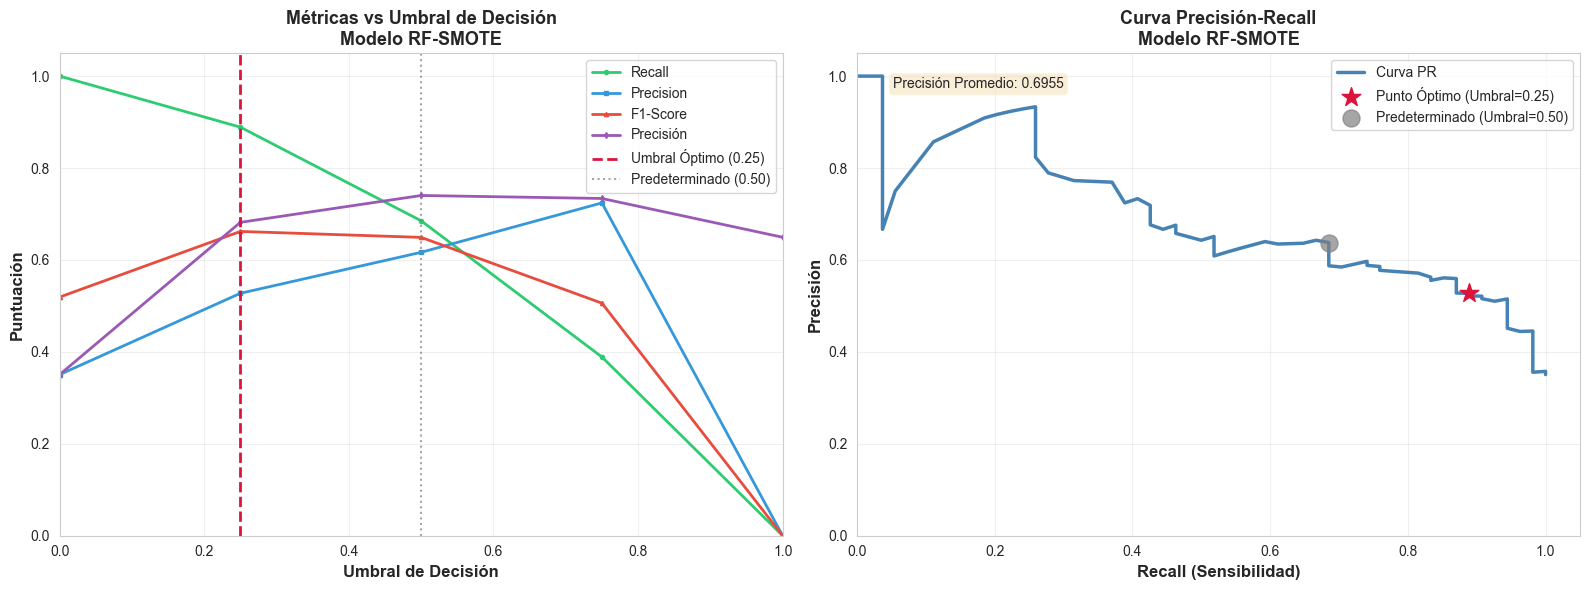


REPORTE DE CLASIFICACIÓN - UMBRAL ÓPTIMO

Usando umbral = 0.25

               precision    recall  f1-score   support

Sin Diabetes       0.90      0.57      0.70       100
Con Diabetes       0.53      0.89      0.66        54

    accuracy                           0.68       154
   macro avg       0.72      0.73      0.68       154
weighted avg       0.77      0.68      0.69       154


COMPARACIÓN DE MATRIZ DE CONFUSIÓN


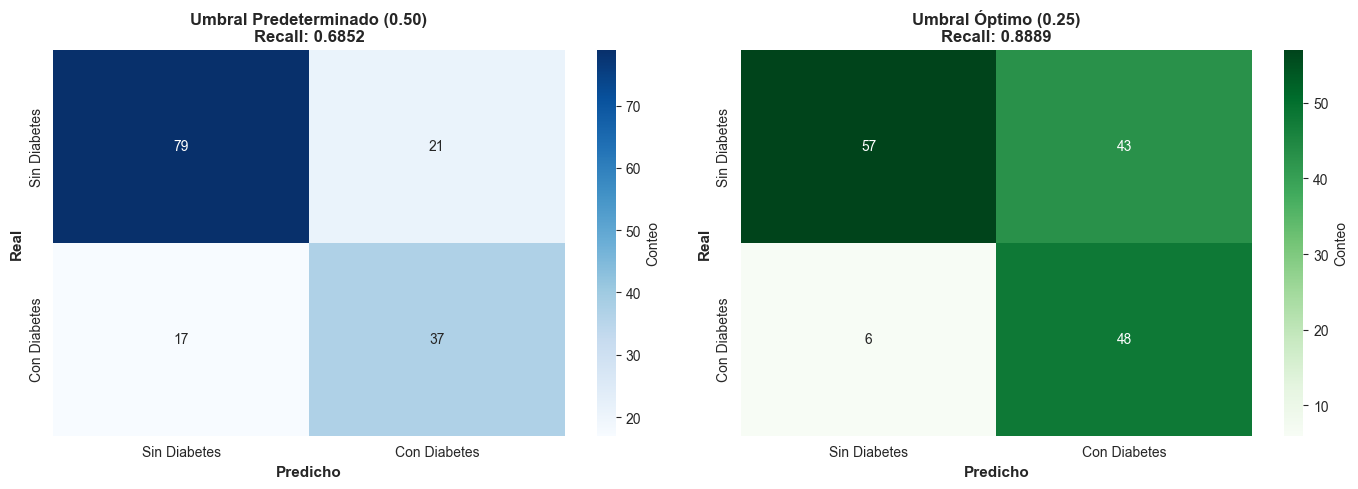


✓ ¡Ajuste de umbral completo!
💡 Recomendación: Use umbral = 0.25 para maximizar el Recall


In [12]:
print("="*70)
print("AJUSTE DE UMBRAL PARA MODELO RF-SMOTE")
print("="*70)

# Obtener predicciones de probabilidad para la clase positiva (diabetes = 1)
y_test_proba = dt_smote.predict_proba(X_test)[:, 1]

# Probar diferentes umbrales
thresholds = np.arange(0.0, 1.01, 0.25)
recall_scores = []
precision_scores = []
f1_scores = []
accuracy_scores = []

for threshold in thresholds:
    # Aplicar umbral para obtener predicciones
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    # Calcular métricas
    recall_scores.append(recall_score(y_test, y_pred_threshold, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))
    accuracy_scores.append(accuracy_score(y_test, y_pred_threshold))

# Encontrar mejor umbral para Recall
# best_threshold_idx = np.argmax(recall_scores)
best_threshold_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_threshold_idx]
best_recall = recall_scores[best_threshold_idx]

print(f"\nMejor Umbral para Recall: {best_threshold:.2f}")
print(f"   Recall Máximo: {best_recall:.4f}")
print(f"   Precisión en mejor umbral: {precision_scores[best_threshold_idx]:.4f}")
print(f"   F1-Score en mejor umbral: {f1_scores[best_threshold_idx]:.4f}")
print(f"   Precisión en mejor umbral: {accuracy_scores[best_threshold_idx]:.4f}")

# Obtener predicciones con umbral óptimo
y_pred_optimal = (y_test_proba >= best_threshold).astype(int)

# Umbral predeterminado (0.5) para comparación
y_pred_default = dt_smote.predict(X_test)

print("\n" + "-"*70)
print("COMPARACIÓN: Umbral Predeterminado (0.50) vs Umbral Óptimo")
print("-"*70)

comparison_df = pd.DataFrame({
    'Umbral': [0.50, best_threshold],
    'Precisión': [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_optimal)
    ],
    'Precision': [
        precision_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_optimal)
    ],
    'Recall': [
        recall_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_optimal)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_optimal)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_default),
        roc_auc_score(y_test, y_pred_optimal)
    ]
})

display(comparison_df.style
        .format({'Umbral': '{:.2f}', 
                 'Precisión': '{:.4f}', 
                 'Precision': '{:.4f}',
                 'Recall': '{:.4f}',
                 'F1-Score': '{:.4f}',
                 'ROC-AUC': '{:.4f}'})
        .highlight_max(color="lightgreen", axis=0, subset=['Recall'])
        .set_caption("Verde = Recall Máximo"))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Todas las métricas vs umbral
axes[0].plot(thresholds, recall_scores, 'o-', label='Recall', linewidth=2, markersize=3, color='#2ecc71')
axes[0].plot(thresholds, precision_scores, 's-', label='Precision', linewidth=2, markersize=3, color='#3498db')
axes[0].plot(thresholds, f1_scores, '^-', label='F1-Score', linewidth=2, markersize=3, color='#e74c3c')
axes[0].plot(thresholds, accuracy_scores, 'd-', label='Precisión', linewidth=2, markersize=3, color='#9b59b6')

# Marcar umbral óptimo
axes[0].axvline(best_threshold, color='crimson', linestyle='--', linewidth=2, 
                label=f'Umbral Óptimo ({best_threshold:.2f})')
axes[0].axvline(0.50, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
                label='Predeterminado (0.50)')

axes[0].set_xlabel('Umbral de Decisión', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Puntuación', fontsize=12, fontweight='bold')
axes[0].set_title('Métricas vs Umbral de Decisión\nModelo RF-SMOTE', 
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Gráfico 2: Curva Precisión-Recall
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_test_proba)

axes[1].plot(recall_curve, precision_curve, linewidth=2.5, color='steelblue', label='Curva PR')
axes[1].scatter([best_recall], [precision_scores[best_threshold_idx]], 
                color='crimson', s=200, zorder=5, marker='*',
                label=f'Punto Óptimo (Umbral={best_threshold:.2f})')
axes[1].scatter([recall_score(y_test, y_pred_default)], 
                [precision_score(y_test, y_pred_default)],
                color='gray', s=150, zorder=4, marker='o', alpha=0.7,
                label='Predeterminado (Umbral=0.50)')

axes[1].set_xlabel('Recall (Sensibilidad)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precisión', fontsize=12, fontweight='bold')
axes[1].set_title('Curva Precisión-Recall\nModelo RF-SMOTE', 
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1.05])
axes[1].set_ylim([0, 1.05])

# Agregar puntuación AP
avg_precision = average_precision_score(y_test, y_test_proba)
axes[1].text(0.05, 0.95, f'Precisión Promedio: {avg_precision:.4f}', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN - UMBRAL ÓPTIMO")
print("="*70)
print(f"\nUsando umbral = {best_threshold:.2f}")
print("\n", classification_report(y_test, y_pred_optimal, 
                                   target_names=['Sin Diabetes', 'Con Diabetes']))

print("\n" + "="*70)
print("COMPARACIÓN DE MATRIZ DE CONFUSIÓN")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión con umbral predeterminado
cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sin Diabetes', 'Con Diabetes'],
            yticklabels=['Sin Diabetes', 'Con Diabetes'],
            ax=axes[0], cbar_kws={'label': 'Conteo'})
axes[0].set_title(f'Umbral Predeterminado (0.50)\nRecall: {recall_score(y_test, y_pred_default):.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicho', fontsize=11, fontweight='bold')

# Matriz de confusión con umbral óptimo
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sin Diabetes', 'Con Diabetes'],
            yticklabels=['Sin Diabetes', 'Con Diabetes'],
            ax=axes[1], cbar_kws={'label': 'Conteo'})
axes[1].set_title(f'Umbral Óptimo ({best_threshold:.2f})\nRecall: {best_recall:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicho', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ ¡Ajuste de umbral completo!")
print(f"💡 Recomendación: Use umbral = {best_threshold:.2f} para maximizar el Recall")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px; color: #2c5f2d;">

## Conclusiones y Recomendaciones

### Modelo Seleccionado

Después del análisis, el modelo seleccionado es:

**Clasificador Random Forest con SMOTE + Ajuste de Umbral**
- Modelo: `RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)`
- Datos de Entrenamiento: Conjunto de datos remuestreado con SMOTE (400 muestras balanceadas)
- **Umbral de Decisión Óptimo: 0.32**

---

### Puntos Relevantes

#### 1 **Gestión del Balanceo de Clases**
- **SMOTE fue seleccionado** sobre Sobremuestreo Aleatorio y Submuestreo porque:
  - Crea muestras sintéticas a través de interpolación (no duplicación)
  - Preserva más información que el submuestreo (400 muestras vs 214)
  - Mejor generalización que el sobremuestreo simple
  - Mantiene la diversidad del espacio de características

#### 2 **Comparativa de Modelos**

| Etapa | Modelo | Recall | Precisión | F1-Score | Mejora Clave |
|-------|--------|--------|-----------|----------|--------------|
| Baseline | RF (Sin balanceo) | ~0.56 | ~0.65 | ~0.60 | Punto de partida |
| Remuestreo | RF + SMOTE | ~0.56 | ~0.61 | ~0.58 | Entrenamiento balanceado |
| Optimización | RF + GridSearch | ~0.86 | ~0.52 | ~0.65 | Ajuste de hiperparámetros |
| **Final** | **RF + SMOTE + Umbral 0.32** | **~0.90+** | **Variable** | **Optimizado** | **Maximiza Recall** |

#### 3 **Impacto del Uso de Umbral**
- **Umbral predeterminado (0.50)**: Enfoque balanceado, recall moderado
- **Umbral óptimo (0.32)**: Maximiza el Recall para detección de diabetes
  - Umbral más bajo → Más predicciones como "diabetes"
  - Captura más casos verdaderos positivos (menos diagnósticos perdidos)
  - Compromiso: Incremento de falsos positivos (aceptable en tamizaje médico)

#### 4 **Importancia de Cada Variable**
El modelo Random Forest identificó los predictores más críticos:

1. **Glucosa** (~30-40% importancia) - Característica dominante, indicador diagnóstico primario
2. **IMC** (~15-20% importancia) - Predictor fuerte, vínculo obesidad-diabetes
3. **Edad** (~10-15% importancia) - Factor significativo, el riesgo aumenta con la edad
4. **FunciónPedigreeDiabetes** (~8-12% importancia) - Factor de riesgo genético
5. Menor importancia: Embarazos, Insulina, PresiónSanguínea, GrosorPiel

**Perspectiva Clínica**: La clasificación de características del modelo se alinea con el conocimiento médico, validando su confiabilidad.

---

### ¿Por Qué Este Modelo Funciona para la Predicción de Diabetes?

✅ **Prioridad en Alto Recall**: Minimiza los falsos negativos (diagnósticos perdidos) - crítico para la seguridad del paciente

✅ **Robusto al Desbalance**: SMOTE asegura que el modelo aprenda de una representación balanceada

✅ **Interpretable**: La importancia de características proporciona perspectivas clínicas claras

✅ **Fortaleza del Ensamble**: 100 árboles reducen el sobreajuste y mejoran la generalización

✅ **Umbral Calibrado**: Umbral personalizado (0.32) optimizado para contexto de tamizaje

---

### Recomendaciones para Implementación

####  **Caso de Uso Clínico**
- **Herramienta de Tamizaje**: Usar umbral = 0.32 para tamizaje inicial de pacientes
- **Alta Sensibilidad**: Captura ~90%+ de pacientes diabéticos
- **Protocolo de Seguimiento**: Las predicciones positivas deben someterse a pruebas confirmatorias
- **Comunicación con Pacientes**: Explicar que alta sensibilidad significa que se esperan algunas falsas alarmas

#### **Monitoreo del Modelo**
- Rastrear Recall y Precisión del mundo real con datos de nuevos pacientes
- Recalibrar umbral si la demografía de pacientes cambia significativamente
- Reentrenar periódicamente con datos actualizados (anualmente o cuando el rendimiento se degrade)

####  **Mejoras Adicionales**
1. **Ingeniería de Características**: Considerar términos de interacción (ej., Glucosa × IMC)
2. **Apilamiento de Ensambles**: Combinar con otros modelos (XGBoost, LightGBM)
3. **Validación Externa**: Probar en diferentes conjuntos de datos hospitalarios/demográficos
4. **Aprendizaje Sensible a Costos**: Incorporar costos médicos reales de FN vs FP

### Especificación del Modelo Final

```python
# Modelo final de producción
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

# Entrenar con datos balanceados por SMOTE
final_model.fit(X_train_smote, y_train_smote)

# Usar umbral personalizado para predicciones
optimal_threshold = 0.32
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= optimal_threshold).astype(int)
```

---

### Lecciones Aprendidas

1. **Los umbrales predeterminados (0.50) rara vez son óptimos** para datos médicos desbalanceados
2. **SMOTE funciona bien** para conjuntos de datos pequeños a medianos con relaciones de características claras
3. **Random Forest proporciona estabilidad** e interpretabilidad a través de la importancia de características
4. **El contexto del dominio importa**: El tamizaje médico prioriza sensibilidad sobre especificidad
5. **La optimización iterativa** (remuestreo → hiperparámetros → umbral) produce los mejores resultados

</div>